# **เก็บรูป JPG**

In [23]:
import cv2
from pathlib import Path
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
DATAPATH = PROJECT_ROOT / "data" / "raw"

print(DATAPATH)
print(DATAPATH.exists())
DATAPATH.mkdir(parents=True, exist_ok=True)

c:\Users\noppa\OneDrive\Desktop\mango\data\raw
True


In [24]:
jpg_img = list(DATAPATH.rglob("*.jpg"))
jpg_img

[WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (1).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (10).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (100).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (101).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (102).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (103).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (104).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (105).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (106).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (107).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (108).jpg'),
 WindowsPath('c:/Users/noppa/OneDri

# **สุ่มรูปของแต่ละเกรด เกรดละ 10 รูป**

In [25]:
import random
from collections import defaultdict

SAMPLES_PER_GRADE = 10
RANDOM_SEED = 42

# จัดกลุ่มรูปตามชื่อโฟลเดอร์เกรด
images_by_grade = defaultdict(list)
for image_path in jpg_img:
    images_by_grade[image_path.parent.name].append(image_path)

# สุ่มรูปโดยไม่ซ้ำกันเกรดละ 10 รูป
rng = random.Random(RANDOM_SEED)
sampled_jpg = {}
for grade in sorted(images_by_grade):
    grade_images = sorted(images_by_grade[grade])
    if len(grade_images) < SAMPLES_PER_GRADE:
        raise ValueError(
            f"เกรด {grade} มีรูปเพียง {len(grade_images)} รูป "
            f"ไม่ถึง {SAMPLES_PER_GRADE} รูป"
        )
    sampled_jpg[grade] = rng.sample(grade_images, SAMPLES_PER_GRADE)

for grade, image_paths in sampled_jpg.items():
    print(f"{grade}: {len(image_paths)} รูป")

sampled_jpg

NDM_M1: 10 รูป
NDM_M2: 10 รูป
NDM_M3: 10 รูป


{'NDM_M1': [WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (26).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (124).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (104).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (5).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (162).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (155).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (150).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (130).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (49).jpg'),
  WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M1/NDM_M1 (122).jpg')],
 'NDM_M2': [WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/raw/NDM_M2/NDM_M2 (9).jpg'),
  Wind

# **แสดงรูป Sample**

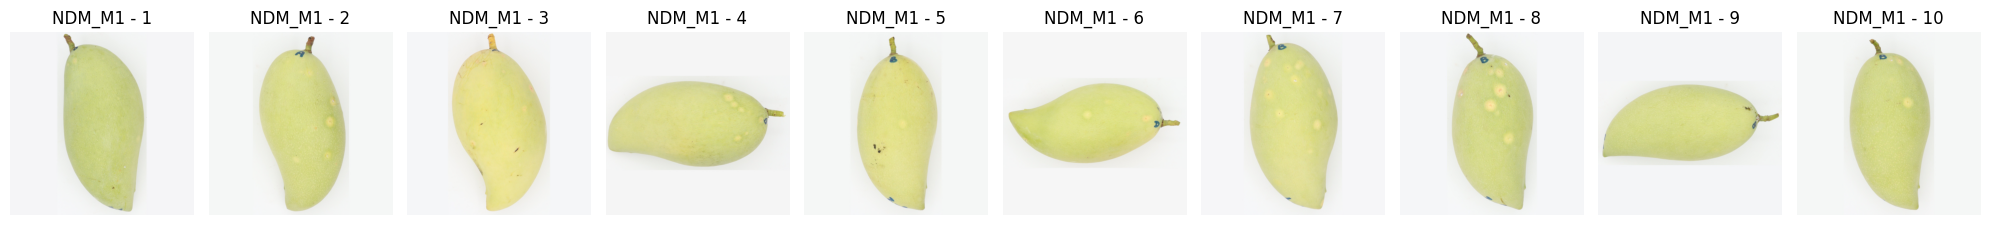

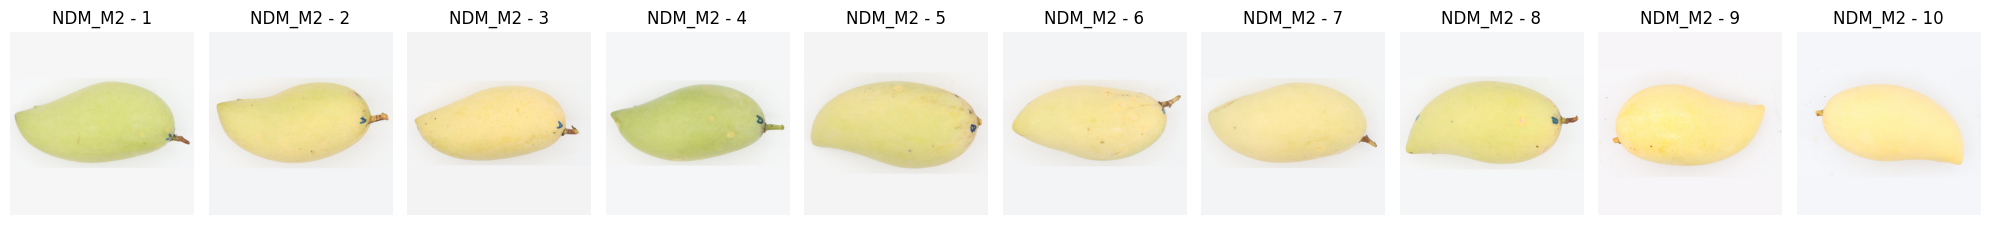

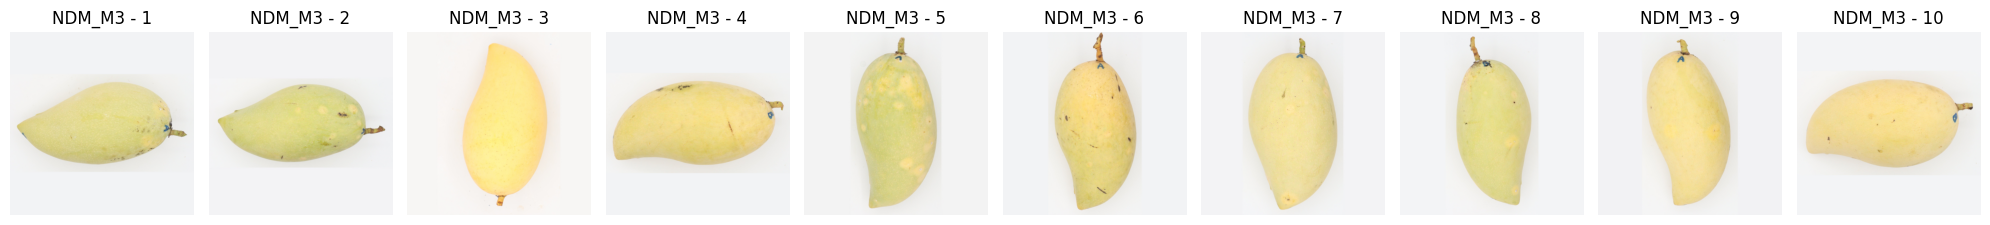

In [26]:
from matplotlib import pyplot as plt

for grade, image_paths in sampled_jpg.items():
    fig, ax = plt.subplots(1, SAMPLES_PER_GRADE, figsize=(20, 5))
    for i, image_path in enumerate(image_paths):
        img = Image.open(image_path)
        ax[i].imshow(img)
        ax[i].axis("off")
        ax[i].set_title(f"{grade} - {i+1}")


    plt.tight_layout()
    plt.show()

# **ทำให้รูปมีขนาดเท่ากัน**

In [27]:
TARGET_SIZE = (1780, 1780)

for grade, image_paths in images_by_grade.items():
    grade_dir = DATAPATH / grade
    grade_dir.mkdir(parents=True, exist_ok=True)

    for source_image_path in image_paths:
        output_image_path = grade_dir / source_image_path.name

        with Image.open(source_image_path) as image:
            image = image.convert("RGB")
            if image.size == TARGET_SIZE:
                resized_image = image.resize(
                    TARGET_SIZE,
                    Image.Resampling.LANCZOS,
                )
                resized_image.save(output_image_path, quality=95)

# **เก็บเป็น Folder ใหม่**

In [28]:
NEW_DATAPATH = PROJECT_ROOT / "data" / "jpg"
NEW_DATAPATH.mkdir(parents=True, exist_ok=True)

for grade, image_paths in images_by_grade.items():
    grade_dir = NEW_DATAPATH / grade
    grade_dir.mkdir(parents=True, exist_ok=True)
    for image_path in image_paths:
        new_image_path = grade_dir / image_path.name
        image = Image.open(image_path)
        image.save(new_image_path)